In [7]:
!pip install transformers torch pandas numpy scikit-learn nbformat kagglehub matplotlib seaborn

zsh:1: command not found: pip


Path to dataset files: /Users/bush/.cache/kagglehub/datasets/threnjen/board-games-database-from-boardgamegeek/versions/4
games: (21925, 48)
user_ratings: (18942215, 3)
mechanics: (21925, 158)
subcategories: (21925, 11)
artist: (21925, 1681)
publisher: (21925, 1866)
Family
18xx                                                  103
Monopoly (Official)                                    73
Trivial Pursuit                                        67
Werewolf / Mafi                                        58
Wallet Games (Button Shy)                              45
                                                     ... 
Holiday Hijinks (Grand Gamers Guild)                    1
WWII Battle Series (Three Crowns Game Productions)      1
Five Parsecs (Nordic Weasel Games)                      1
Great Western Trail                                     1
Smartphone Inc.                                         1
Name: count, Length: 1456, dtype: int64

count    1456.000000
mean        4.576236
std   

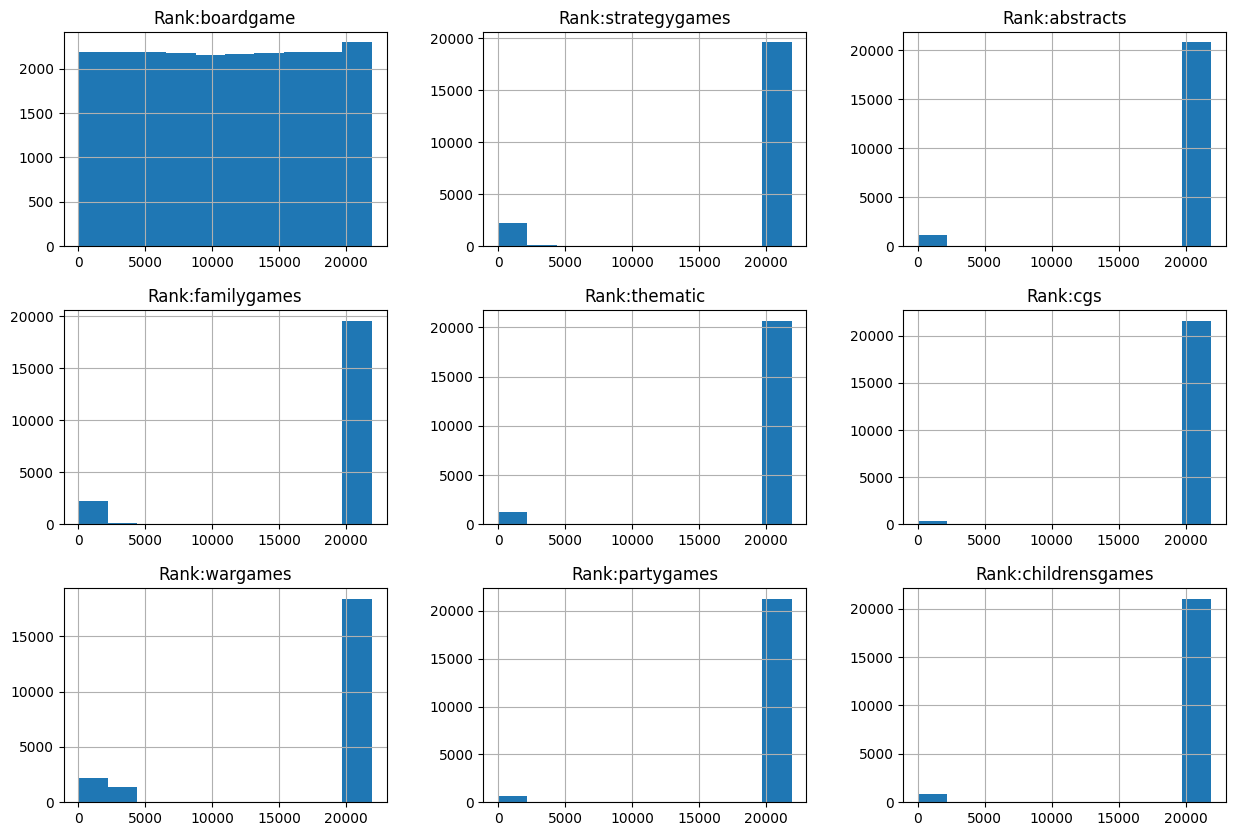

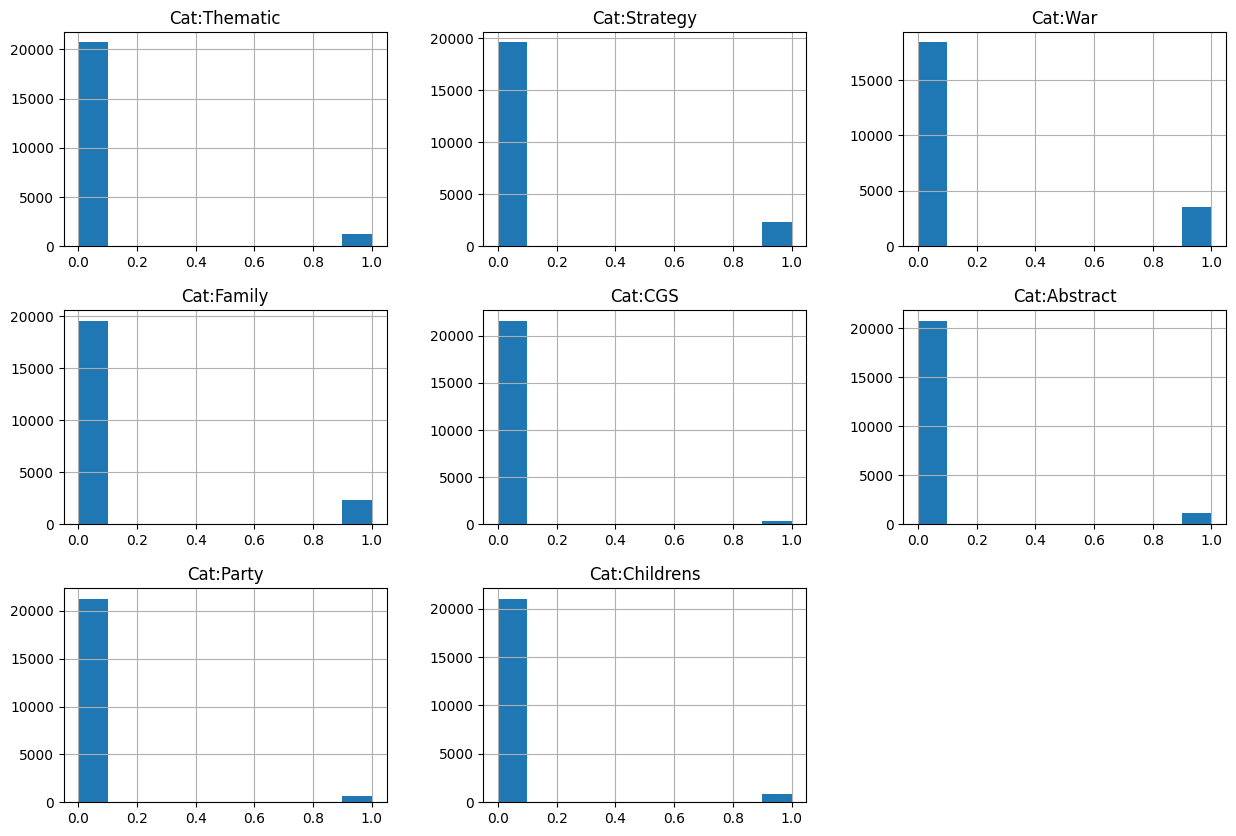

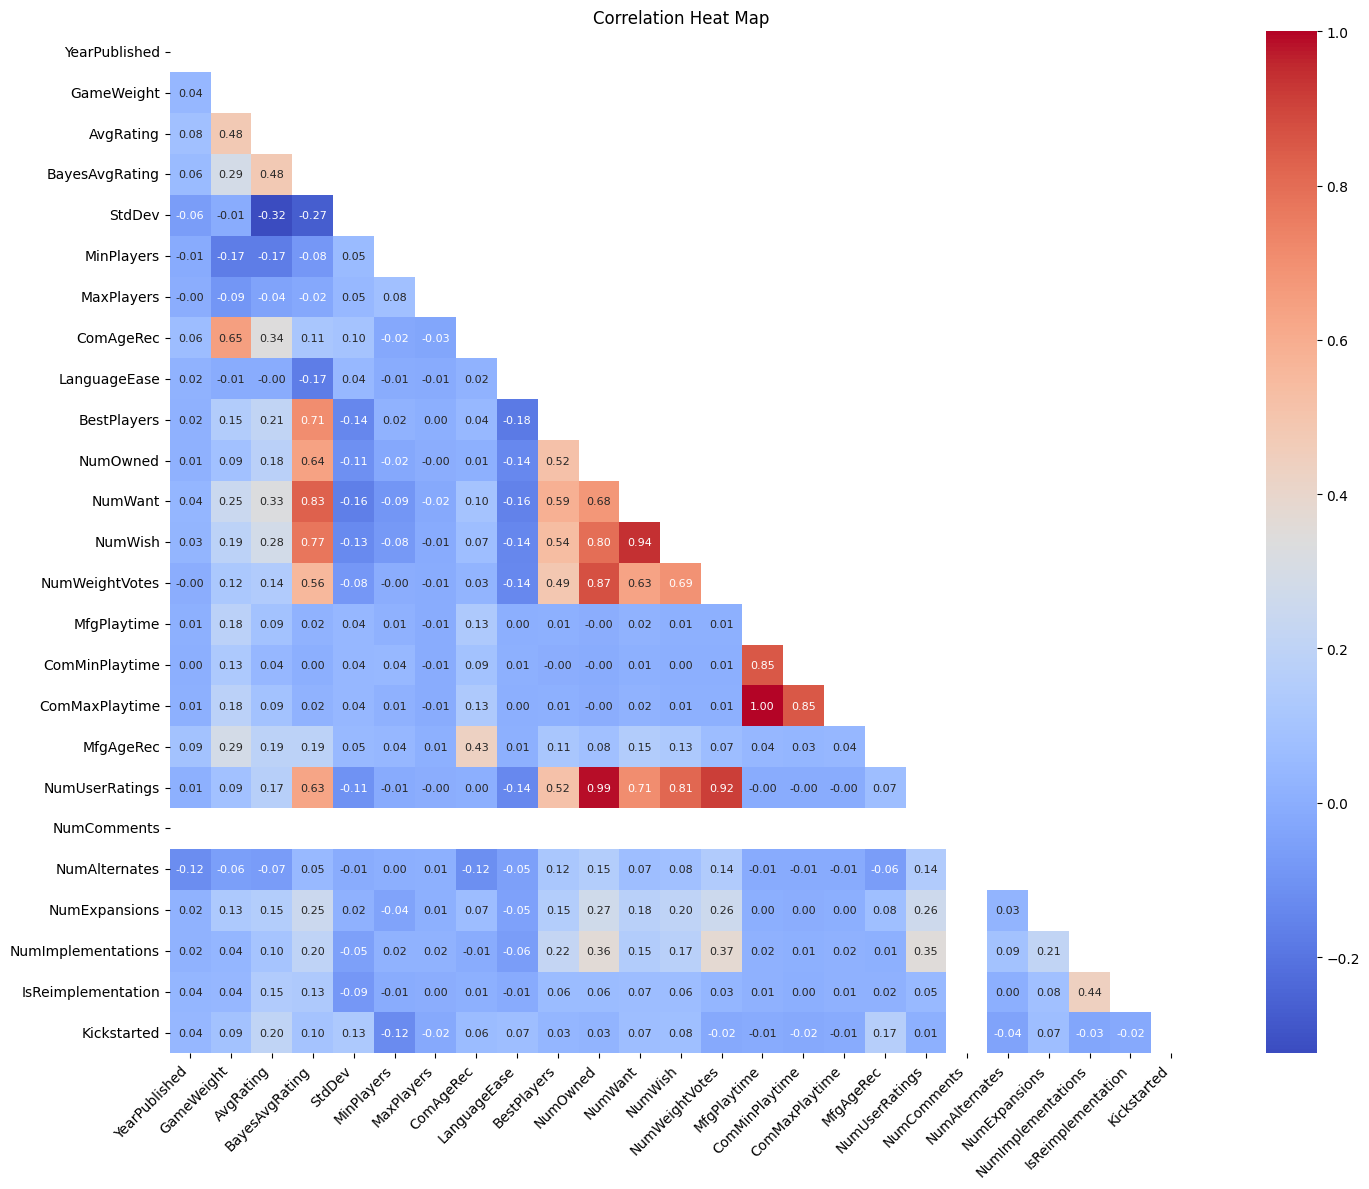

<class 'pandas.DataFrame'>
RangeIndex: 21925 entries, 0 to 21924
Columns: 1866 entries, Hans im Glück to Low-Exp Publisher
dtypes: int64(1866)
memory usage: 312.1 MB


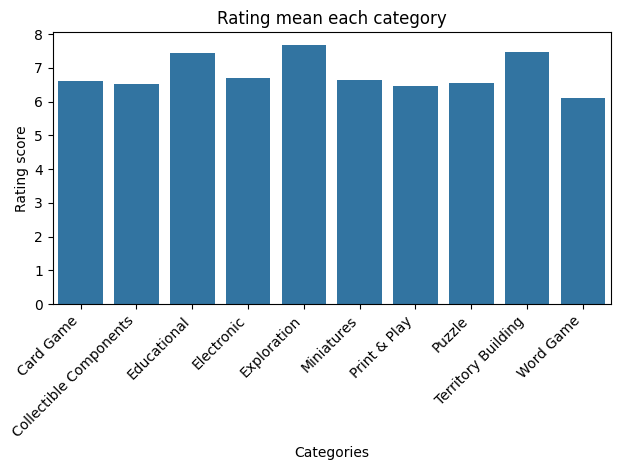

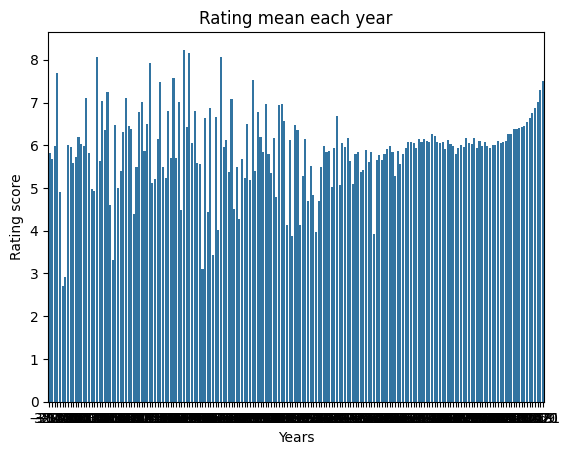

Ratings per user — summary stats
count    411374.000000
mean         46.046060
std         108.431797
min           1.000000
25%           2.000000
50%          12.000000
75%          44.000000
max        6493.000000

Threshold              % of users
<= 5                        36.7%
<= 10                       47.2%
<= 20                       59.9%
<= 50                       77.6%
<= 100                      88.4%


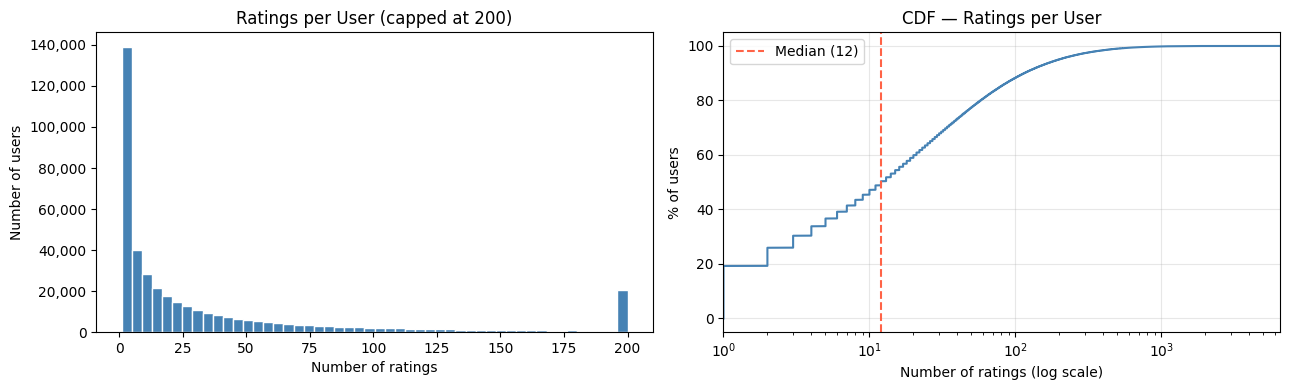

Top 10 most-rated games:


,Ratings,% of all
Game,,
Pandemic,107760,0.569
Carcassonne,107601,0.568
Catan,106725,0.563
7 Wonders,89014,0.470
Dominion,80901,0.427
Ticket to Ride,75352,0.398
Codenames,73188,0.386
Terraforming Mars,72753,0.384
7 Wonders Duel,68063,0.359



Top  1% of games ( 219 titles) → 33.8% of all ratings
Top 10% of games (2192 titles) → 76.7% of all ratings

Games with  <50 ratings : 19.9%
Games with <100 ratings : 43.9%

Catan: 106,725 ratings  (0.563% of all)
Pandemic: 107,760 ratings  (0.569% of all)


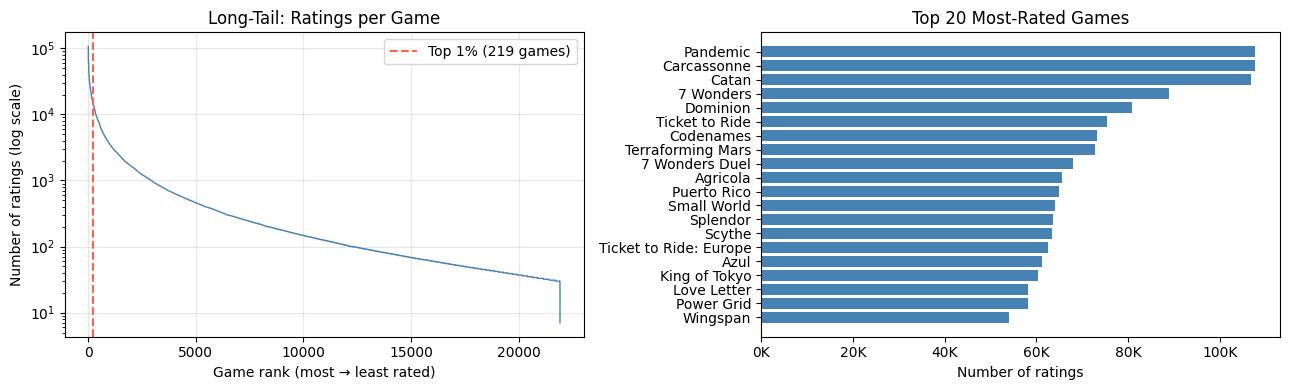

Path to dataset files: /Users/bush/.cache/kagglehub/datasets/threnjen/board-games-database-from-boardgamegeek/versions/4
games: (21925, 48)
user_ratings: (18942215, 3)
mechanics: (21925, 158)
subcategories: (21925, 11)
Ratings after filtering users with <5 ratings: 18,696,365
Users remaining: 272,184

Train: 14,957,092
Val: 1,869,636
Test: 1,869,637

Global mean (train): 7.1118
Popularity baseline (per-game mean)
RMSE: 1.3183
MAE: 1.0004

Top 10 games to recommend (by number of train ratings):


,Name,n_ratings,avg_rating
0,Pandemic,84389,7.638829
1,Carcassonne,83985,7.454927
2,Catan,82495,7.170982
3,7 Wonders,69947,7.780845
4,Dominion,63548,7.647983
5,Ticket to Ride,59363,7.456481
6,Codenames,57950,7.675544
7,Terraforming Mars,55356,8.505254
8,7 Wonders Duel,53136,8.183961
9,Agricola,51356,7.971187


Users with >= 20 train ratings: 150,634
Sampled 15,000 users  |  1,350,517 ratings

Sparse matrix shape: (15000, 21538)
Stored values: 1,348,330
Similarity matrix shape: (15000, 15000)
Test pairs evaluable by KNN : 167,327  (of 1,869,637 total)

User-Based KNN (k=40)
RMSE: 1.3072
MAE: 0.9980


,Model,RMSE,MAE
0,User-Based KNN (k=40),1.3072,0.9980
1,Popularity (per-game mean),1.3183,1.0004


/var/folders/cy/409w3plj3vd3ps5d7mt5q4hh0000gn/T/ipykernel_26081/2534053767.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results['Model'], rotation=10, ha='right')
/var/folders/cy/409w3plj3vd3ps5d7mt5q4hh0000gn/T/ipykernel_26081/2534053767.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(results['Model'], rotation=10, ha='right')


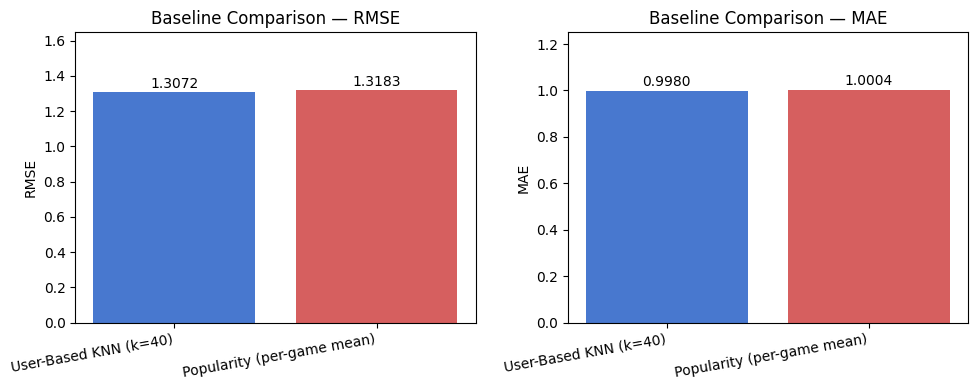

Popularity Precision@10: 0.0366
Popularity Recall@10: 0.0672
(same 10 games recommended to all 14,374 users)
KNN Precision@10: 0.0022
KNN Recall@10: 0.0042
Averaged over 14,374 users

Ranking Summary (K=10, threshold >= 7.0):
Popularity Precision@10: 0.0366 Recall@10: 0.0672
KNN Precision@10: 0.0022 Recall@10: 0.0042


In [8]:
%run "eda.ipynb"
%run "baselines.ipynb"

In [14]:
import torch
import pandas as pd
from transformers import AutoModelForCausalLM, AutoTokenizer
from tqdm import tqdm
import os

In [15]:
#%who DataFrame
games_with_mechs = games.merge(mechanics, on='BGGId', how='left')
# Identify which columns are actually mechanics (everything except BGGId)
mech_cols = [c for c in mechanics.columns if c != 'BGGId']

In [19]:
class LLMPredictorVariant:
    
    def __init__(self, model_name="gpt2"): 
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModelForCausalLM.from_pretrained(model_name)
        
        # Token IDs for '1' through '10' to calculate expected value
        self.target_tokens = [str(i) for i in range(1, 11)]
        self.target_token_ids = [self.tokenizer.encode(t)[-1] for t in self.target_tokens]

        #SPEEDUP: merge once at init instead of once per predict_rating call ---
        # Before: user_ratings.merge(...) ran inside predict_rating on every prediction
        # After:  merged result stored as self.user_data and reused for all predictions
        self.user_data = user_ratings.merge(games[['BGGId', 'Name']], on='BGGId', how='left')
    
    def get_mechanics_list(self, row, mechanics_columns):
        """Finds all columns where value is 1 and returns them as a comma-separated string."""
        active_mechs = [col for col in mechanics_columns if row[col] == 1]
        return ", ".join(active_mechs) if active_mechs else "General Play"

    def create_prompt(self, user_history, target_game_meta):
        history_str = "\n".join([f"- {row['Name']}: {row['Rating']}/10" for _, row in user_history.iterrows()])
        
        prompt = f"""
You are a board game expert. Based on the user's past ratings, predict their rating (1-10) for the target game.

User's Rated Games:
{history_str}

Target Game attributes:
- Name: {target_game_meta['Name']}
- Mechanics: {target_game_meta['boardgamemechanic']}
- Complexity: {target_game_meta['averageweight']:.2f}/5
- Theme: {target_game_meta.get('boardgamecategory', 'General')}

Analyze the user's preference for {target_game_meta['boardgamemechanic']}. 
Based on this analysis and based on the alignment between the user's history and these mechanics, the predicted rating for {target_game_meta['Name']} is:"""
        return prompt

    def predict_rating(self, user_id, game_id):
        user_id = str(user_id)
        game_id = int(game_id)

        target_selection = games_with_mechs[games_with_mechs['BGGId'] == game_id]

        if target_selection.empty:
            return None

        target_row = target_selection.iloc[0]

        # Use precomputed self.user_data instead of merging on every call
        readable_mechanics = self.get_mechanics_list(target_row, mech_cols)
        user_history = self.user_data[self.user_data['Username'] == user_id].head(5)

        target_game_meta = {
            'Name': target_row['Name'],
            'boardgamemechanic': readable_mechanics,
            'averageweight': target_row['GameWeight'],
            'boardgamecategory': target_row.get('boardgamecategory', 'Tabletop')
        }
        
        prompt = self.create_prompt(user_history, target_game_meta)
        inputs = self.tokenizer(prompt, return_tensors="pt")
        
        with torch.no_grad():
            outputs = self.model(**inputs)
            
        last_token_logits = outputs.logits[0, -1, :]
        target_logits = last_token_logits[self.target_token_ids]
        probabilities = torch.softmax(target_logits, dim=-1)
        
        ratings = torch.tensor([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=torch.float32)
        return torch.sum(probabilities * ratings).item()

In [20]:
# --- Execution & Comparison ---
variant_c = LLMPredictorVariant()

# Example test on a user/item pair from the test set
sample_user = 753
sample_game = 5
prediction = variant_c.predict_rating(sample_user, sample_game)

print(f"\n--- Variant C Results ---")
if prediction is not None:
    print(f"Predicted Rating: {prediction:.2f}")
else:
    print("Predicted Rating: N/A (Game not found in metadata)")

actual_ratings = []
predicted_ratings = []

for idx, row in tqdm(test.iterrows(), total=len(test)):
    user_id = row['Username']
    game_id = row['BGGId']
    true_rating = row['Rating']
    
    if prediction is not None:
        actual_ratings.append(true_rating)
        predicted_ratings.append(prediction)

if len(predicted_ratings) > 0:
    variant_rmse = rmse(actual_ratings, predicted_ratings)
    print(f"\n--- LLM-based Variant Performance ---")
    print(f"Variation RMSE: {variant_rmse:.4f}")
else:
    print("No predictions were generated.")

print(f"--- Baseline Comparison ---")
print(f"Popularity RMSE: {rmse_pop:.4f}")
print(f"KNN RMSE: {rmse_knn:.4f}")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]


--- Variant C Results ---
Predicted Rating: 3.01


100%|██████████| 1869637/1869637 [00:14<00:00, 129630.18it/s]


--- LLM-based Variant Performance ---
Variation RMSE: 4.3761
--- Baseline Comparison ---
Popularity RMSE: 1.3183
KNN RMSE: 1.3072


In [21]:
K_RANK = 10
THRESHOLD = 7.0
SAVE_PATH = "llm_ranking_results.csv"

unique_test_users = test['Username'].unique()[:20]
all_test_users = test['Username'].unique()

if os.path.exists(SAVE_PATH):
    results_df = pd.read_csv(SAVE_PATH)
    processed_users = set(results_df['Username'].unique())
    print(f"Resuming: {len(processed_users)} users already processed.")
else:
    results_df = pd.DataFrame(columns=['Username', 'Precision', 'Recall'])
    processed_users = set()

temp_results = []

for username in tqdm(unique_test_users):
    if username in processed_users:
        continue
        
    user_test_data = test[test['Username'] == username]
    liked_games = user_test_data[user_test_data['Rating'] >= THRESHOLD]['BGGId'].tolist()
    
    if not liked_games:
        continue 
        
    relevant_set = set(liked_games)
    predictions = []
    
    # Predict for each game the user rated in the test set
    for _, row in user_test_data.iterrows():
        #try:
        pred_rating = variant_c.predict_rating(row['Username'], row['BGGId'])
        #except KeyError:
        #    pred_rating = None
        if pred_rating is not None:
            predictions.append((row['BGGId'], pred_rating))
    
    # Ranking logic
    predictions.sort(key=lambda x: x[1], reverse=True)
    top_k_recommended = [item[0] for item in predictions[:K_RANK]]
    
    hits = len(set(top_k_recommended) & relevant_set)
    p_at_k = hits / K_RANK
    r_at_k = hits / len(relevant_set)
    
    temp_results.append({'Username': username, 'Precision': p_at_k, 'Recall': r_at_k})
    
    if len(temp_results) >= 10:
        batch_df = pd.DataFrame(temp_results)
        batch_df.to_csv(SAVE_PATH, mode='a', header=not os.path.exists(SAVE_PATH), index=False)
        temp_results = [] 

if temp_results:
    pd.DataFrame(temp_results).to_csv(SAVE_PATH, mode='a', header=False, index=False)

final_results = pd.read_csv(SAVE_PATH)
print(f"\n--- Final Results Summary ({len(final_results)} Users) ---")
print(f"Mean Precision@{K_RANK}: {final_results['Precision'].mean():.4f}")
print(f"Mean Recall@{K_RANK}: {final_results['Recall'].mean():.4f}")


100%|██████████| 20/20 [08:25<00:00, 25.27s/it]


--- Final Results Summary (20 Users) ---
Mean Precision@10: 0.6700
Mean Recall@10: 0.6696
